In [1]:
# Copyright © 2026 Rioborue Alexander Oghenerume. All rights reserved.
# This code cannot be used, modified, or distributed without permission.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
STATISTICIAN_BANNER = "© R.A. Oghenerume. All Rights Reserved."
def print_banner():
    line = "=" * 70
    print(line)
    print(STATISTICIAN_BANNER.center(70))
    print(line)
print_banner()
try:
    from google.colab import files
    print("Please upload: Cronbach.xlsx")
    uploaded = files.upload()
    # Confirm the exact filename that was uploaded
    print("Uploaded file(s):", list(uploaded.keys()))
except ImportError:
    print("Not running in Colab — expecting 'Cronbach.xlsx' in the working directory.")

               © R.A. Oghenerume. All Rights Reserved.                
Please upload: Cronbach.xlsx


Saving Cronbach.xlsx to Cronbach.xlsx
Uploaded file(s): ['Cronbach.xlsx']


In [2]:
INPUT_FILE  = 'Cronbach.xlsx'
OUTPUT_FILE = 'reliability_30.xlsx'
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"'{INPUT_FILE}' not found in {os.getcwd()}.\n"
        f"Files present: {os.listdir()}\n"
        f"Re-run the upload cell and make sure the file is named exactly 'Cronbach.xlsx'."
    )
df = pd.read_excel(INPUT_FILE)
print("=" * 70)
print(f"Loaded : {INPUT_FILE}")
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print("=" * 70)

Loaded : Cronbach.xlsx
Shape  : (30, 20)
Columns: ['AI1', 'AI2', 'AI3', 'AI4', 'AI5', 'BCT1', 'BCT2', 'BCT3', 'BCT4', 'BCT5', 'BDA1', 'BDA2', 'BDA3', 'BDA4', 'BDA5', 'FFI1', 'FFI2', 'FFI3', 'FFI4', 'FFI5']


In [3]:
CONSTRUCTS = {
    'AI' : {
        'label': 'Artificial Intelligence',
        'items': ['AI1', 'AI2', 'AI3', 'AI4', 'AI5'],
    },
    'BCT': {
        'label': 'Blockchain Technology',
        'items': ['BCT1', 'BCT2', 'BCT3', 'BCT4', 'BCT5'],
    },
    'BDA': {
        'label': 'Big Data Analytics',
        'items': ['BDA1', 'BDA2', 'BDA3', 'BDA4', 'BDA5'],
    },
    'FFI': {
        'label': 'Perceived Effectiveness of Forensic Fraud Investigation',
        'items': ['FFI1', 'FFI2', 'FFI3', 'FFI4', 'FFI5'],
    },
}

In [4]:
def cronbach_alpha(items_df: pd.DataFrame) -> float:
    """Compute Cronbach's alpha for a set of item columns."""
    k = items_df.shape[1]
    item_var  = items_df.var(axis=0, ddof=1).sum()
    total_var = items_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

def interpret(alpha: float) -> str:
    if alpha >= 0.90: return 'Excellent'
    if alpha >= 0.80: return 'Good'
    if alpha >= 0.70: return 'Acceptable'
    if alpha >= 0.60: return 'Questionable'
    return 'Poor'

In [5]:
rows = []
for code, meta in CONSTRUCTS.items():
    items = df[meta['items']]
    a = cronbach_alpha(items)
    rows.append({
        'Construct'     : code,
        'Description'   : meta['label'],
        'No. of Items'  : len(meta['items']),
        "Cronbach's α"  : round(a, 3),
        'Interpretation': interpret(a),
    })
reliability_tbl = pd.DataFrame(rows)
print("\n" + "=" * 70)
print("RELIABILITY ANALYSIS — CRONBACH'S ALPHA")
print("=" * 70)
print(reliability_tbl.to_string(index=False))


RELIABILITY ANALYSIS — CRONBACH'S ALPHA
Construct                                             Description  No. of Items  Cronbach's α Interpretation
       AI                                 Artificial Intelligence             5         0.908      Excellent
      BCT                                   Blockchain Technology             5         0.931      Excellent
      BDA                                      Big Data Analytics             5         0.945      Excellent
      FFI Perceived Effectiveness of Forensic Fraud Investigation             5         0.925      Excellent


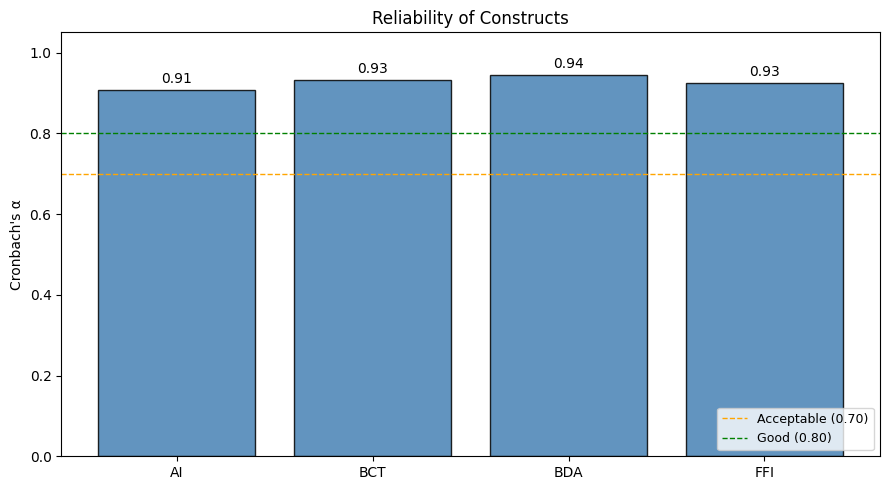

Chart saved as: reliability_30.png

                    RELIABILITY ANALYSIS COMPLETE                     
               © R.A. Oghenerume. All Rights Reserved.                


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(reliability_tbl['Construct'],
              reliability_tbl["Cronbach's α"],
              color='steelblue', edgecolor='k', alpha=0.85)

ax.axhline(0.70, color='orange', linestyle='--', linewidth=1,
           label='Acceptable (0.70)')
ax.axhline(0.80, color='green', linestyle='--', linewidth=1,
           label='Good (0.80)')

for bar, a in zip(bars, reliability_tbl["Cronbach's α"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{a:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Cronbach's α")
ax.set_title("Reliability of Constructs", fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('reliability_30.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as: reliability_30.png")

print("\n" + "=" * 70)
print("RELIABILITY ANALYSIS COMPLETE".center(70))
print(STATISTICIAN_BANNER.center(70))
print("=" * 70)